Plotting paired figure:
  CMIP5: corrdiff_pred_id-011_sample-10_CNRM-CM5_ALADIN63_2090-2099_drought_metrics.nc
  CMIP6: corrdiff_pred_id-012_sample-10_CNRM-CM6-1_ALADIN-like_2090-2099_drought_metrics.nc


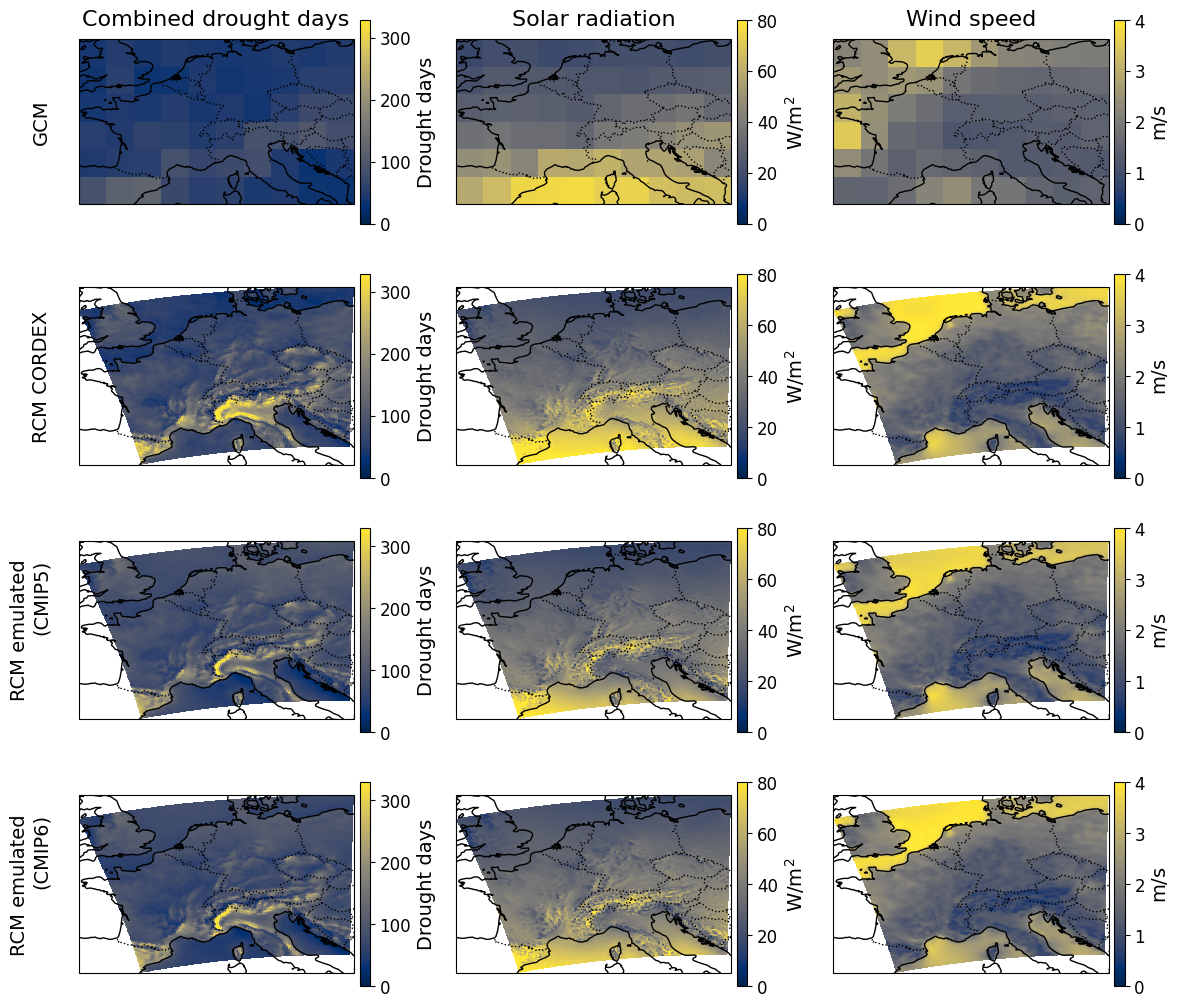

Saved ../plots/0106_drought_panels_attached_id-011_sample-10_CNRM-CM5_ALADIN63_2090-2099_drought_metrics.pdf
Plotting paired figure:
  CMIP5: corrdiff_pred_id-011_sample-10_CNRM-CM5_CCLM4-8-17_2090-2099_drought_metrics.nc
  CMIP6: corrdiff_pred_id-012_sample-10_CNRM-CM6-1_CCLM-like_2090-2099_drought_metrics.nc


KeyboardInterrupt: 

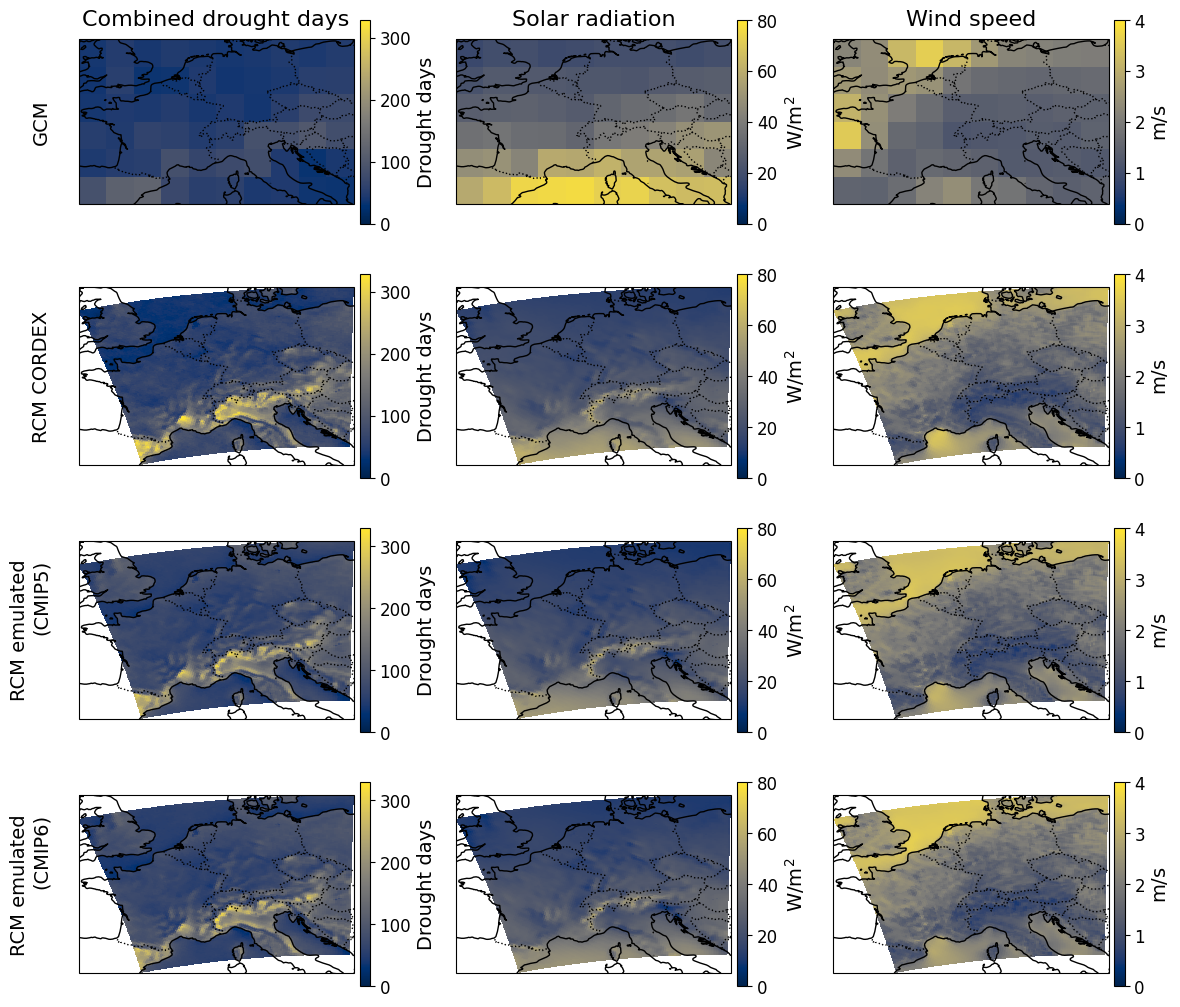

In [2]:
import glob
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr

# Matplotlib global style configuration
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

# Reference spatial grid
grid_path = "../plotting_data/0047_temp_mean_subset.nc"
orig_data = xr.open_dataset(grid_path)
lons = orig_data.lon.values
lats = orig_data.lat.values

# Folder paths
cmip5_folder = "../plotting_data/results_matrices/"
cmip6_folder = (
    "../plotting_data/results_matrices/cmip6"
)

cmip5_files = sorted(glob.glob(os.path.join(cmip5_folder, "corrdiff_*.nc")))
cmip6_files = sorted(glob.glob(os.path.join(cmip6_folder, "corrdiff_*.nc")))

# --- Explicit GCM & RCM Model Mappings ---
GCM_MAP = {
    "CNRM-CM5": "CNRM-CM6-1",
    "MIROC5": "MIROC6",
    "MPI-ESM-LR": "MPI-ESM1-2-LR",
}

RCM_MAP = {
    "ALADIN63": "ALADIN-like",
    "CCLM4-8-17": "CCLM-like",
    "RegCM4-6": "RegCM-like",
    "REMO2015": "REMO-like",
}


def find_cmip6_match(f_cmip5, cmip6_file_list):
    """Parses GCM and RCM from CMIP5 filename and finds the corresponding CMIP6 file."""
    filename = os.path.basename(f_cmip5)

    matched_gcm = next((g for g in GCM_MAP if g in filename), None)
    matched_rcm = next((r for r in RCM_MAP if r in filename), None)

    if not matched_gcm or not matched_rcm:
        return None

    target_gcm = GCM_MAP[matched_gcm]
    target_rcm = RCM_MAP[matched_rcm]

    for f in cmip6_file_list:
        if target_gcm in f and target_rcm in f:
            return f

    return None


def plot_panel(
    fig,
    ax,
    data,
    lons=lons,
    lats=lats,
    cmap="cividis",
    label="Value",
    vmin=None,
    vmax=None,
):
    data_2d = data.squeeze()

    im = ax.pcolormesh(
        lons,
        lats,
        data_2d.values if hasattr(data_2d, "values") else data_2d,
        cmap=cmap,
        shading="auto",
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    cb = fig.colorbar(
        im, ax=ax, orientation="vertical", fraction=0.035, pad=0.02
    )
    cb.set_label(label)


vminmax = {"combined": (0, 0.09 * 3652), "solar": (0, 80), "wind": (0, 4)}

for f_cmip5 in cmip5_files:
    fname = os.path.basename(f_cmip5)
    f_cmip6 = find_cmip6_match(f_cmip5, cmip6_files)

    if f_cmip6 is None:
        print(f"Skipping {fname} - no corresponding CMIP6 match found.")
        continue

    print(
        f"Plotting paired figure:\n  CMIP5: {fname}\n  CMIP6: {os.path.basename(f_cmip6)}"
    )

    ds_cmip5 = xr.open_dataset(f_cmip5)
    ds_cmip6 = xr.open_dataset(f_cmip6)

    save_id = fname.replace("corrdiff_pred_", "").replace(".nc", "")

    fig, axes = plt.subplots(
        4, 3, figsize=(12, 10.5), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    col_titles = ["Combined drought days", "Solar radiation", "Wind speed"]
    for i, title in enumerate(col_titles):
        axes[0, i].set_title(title, pad=10)

    # --- Row 1: GCM ---
    plot_panel(
        fig,
        axes[0, 0],
        ds_cmip5["combined_GCM"] * 3652,
        lons=ds_cmip5["combined_GCM"].lon,
        lats=ds_cmip5["combined_GCM"].lat,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        fig,
        axes[0, 1],
        ds_cmip5["solar_GCM"],
        lons=ds_cmip5["solar_GCM"].lon,
        lats=ds_cmip5["solar_GCM"].lat,
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        fig,
        axes[0, 2],
        ds_cmip5["wind_GCM"],
        lons=ds_cmip5["wind_GCM"].lon,
        lats=ds_cmip5["wind_GCM"].lat,
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[0, 0].text(
        -0.1,
        0.5,
        "GCM",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[0, 0].transAxes,
    )

    # --- Row 2: RCM CORDEX ---
    plot_panel(
        fig,
        axes[1, 0],
        ds_cmip5["combined_RCM_truth"] * 3652,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        fig,
        axes[1, 1],
        ds_cmip5["solar_RCM_truth"],
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        fig,
        axes[1, 2],
        ds_cmip5["wind_RCM_truth"],
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[1, 0].text(
        -0.1,
        0.5,
        "RCM CORDEX",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[1, 0].transAxes,
    )

    # --- Row 3: RCM Emulated (CMIP5) ---
    plot_panel(
        fig,
        axes[2, 0],
        ds_cmip5["combined_RCM_emulated"] * 3652,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        fig,
        axes[2, 1],
        ds_cmip5["solar_RCM_emulated"],
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        fig,
        axes[2, 2],
        ds_cmip5["wind_RCM_emulated"],
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[2, 0].text(
        -0.1,
        0.5,
        "RCM emulated\n(CMIP5)",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[2, 0].transAxes,
    )

    # --- Row 4: RCM Emulated (CMIP6) ---
    plot_panel(
        fig,
        axes[3, 0],
        ds_cmip6["combined_RCM_emulated"] * 3652,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        fig,
        axes[3, 1],
        ds_cmip6["solar_RCM_emulated"],
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        fig,
        axes[3, 2],
        ds_cmip6["wind_RCM_emulated"],
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[3, 0].text(
        -0.1,
        0.5,
        "RCM emulated\n(CMIP6)",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[3, 0].transAxes,
    )

    plt.tight_layout()
    out_path = f"../plots/0106_drought_panels_attached_{save_id}.pdf"
    plt.savefig(out_path)
    plt.show()
    print(f"Saved {out_path}")